In [1]:
# import os; import psutil; import timeit
# from datasets import load_dataset

# mem_before = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
# wiki = load_dataset("wikipedia", "20220301.en", split="train", trust_remote_code=True)
# mem_after = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# print(f"RAM memory used: {(mem_after - mem_before)} MB")

# wiki.save_to_disk("wikipedia-en-train")

In [2]:
from datasets import load_from_disk
import os; import psutil; import timeit

mem_before = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
wiki = load_from_disk("wikipedia-en-train")
mem_after = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
print(f"RAM memory used: {(mem_after - mem_before)} MB")

Loading dataset from disk:   0%|          | 0/41 [00:00<?, ?it/s]

RAM memory used: 55.43359375 MB


In [3]:
sample_text = wiki.select(range(3))["text"][0]
sample_text.encode()

b'Anarchism is a political philosophy and movement that is sceptical of authority and rejects all involuntary, coercive forms of hierarchy. Anarchism calls for the abolition of the state, which it holds to be unnecessary, undesirable, and harmful. As a historically left-wing movement, placed on the farthest left of the political spectrum, it is usually described alongside communalism and libertarian Marxism as the libertarian wing (libertarian socialism) of the socialist movement, and has a strong historical association with anti-capitalism and socialism.\n\nHumans lived in societies without formal hierarchies long before the establishment of formal states, realms, or empires. With the rise of organised hierarchical bodies, scepticism toward authority also rose. Although traces of anarchist thought are found throughout history, modern anarchism emerged from the Enlightenment. During the latter half of the 19th and the first decades of the 20th century, the anarchist movement flourished

In [4]:
shuffled_wiki = wiki.shuffle()

In [5]:
shuffled_wiki.select(range(3))[1]

{'id': '33907335',
 'url': 'https://en.wikipedia.org/wiki/List%20of%20Downton%20Abbey%20characters',
 'title': 'List of Downton Abbey characters',
 'text': 'This is a list of characters from Downton Abbey, a British period drama television series created by Julian Fellowes and co-produced by Carnival Films and Masterpiece for ITV and PBS, respectively.\n\nCast\n\nMain cast\n\nRecurring cast\n\nGuest cast\n\nThe Crawley family\n\nRobert Crawley, 7th Earl of Grantham  \nRobert Crawley, 7th Earl of Grantham (played by Hugh Bonneville) (b. 1866) is the current Earl of Grantham. He is the husband of Cora, son of Violet, and father of Mary, Edith and Sybil. Robert is immensely proud of Downton as the place he grew up and takes his responsibility for the estate very seriously. Although in some ways his character embodies the traditional values of the aristocracy, Robert does not shun all progress, and he is very protective of and loyal to his family and servants. Despite these virtues, Robert

In [6]:
MASK_ID = -100

def batch_tokenize(batch, context_window_size = 512):
    """
    batch: list of conversations, which can be tokenized using tokenizer.apply_chat_template
    output: dict with 'input_ids' and 'labels', each being a list of lists of ints, without padding
        that is, each of the lists within the batch may have different lengths
    """
    input_ids, labels = [], []

    for text in batch['text']:
        all_tokens = text[:context_window_size].encode("utf-8")
        tokens = all_tokens[:context_window_size]
        input_ids.append(tokens)

    return {'input_ids': input_ids}

batch = shuffled_wiki.select(range(3))
output = batch_tokenize(batch)
input_ids = output['input_ids'][0]

In [7]:
tokenized_wiki = shuffled_wiki.select(range(10000)).map(batch_tokenize, batched=True, num_proc=8, remove_columns=wiki.column_names)

Map (num_proc=8):   0%|          | 0/10000 [00:00<?, ? examples/s]

In [8]:
tokenized_wiki

Dataset({
    features: ['input_ids'],
    num_rows: 10000
})

In [9]:
import torch
pad_token_id = 256

def pad_sft_collator(batch, padding_value: int=pad_token_id, padding_side = "left"):
    # TODO: implement this function
    tensor_batch_ids = [torch.tensor(list(x['input_ids'])) for x in batch]

    input_ids = torch.nn.utils.rnn.pad_sequence(
        tensor_batch_ids,
        padding_value=padding_value,
        padding_side=padding_side,
        ).T

    attention_mask = []
    max_len = input_ids.shape[-1]
    for ids in tensor_batch_ids:
        ids_len = len(ids)
        if padding_side == "left":
            new_mask = torch.tensor([0]*(max_len-ids_len) + [1]*ids_len)
        else:
            new_mask = torch.tensor([1]*ids_len + [0]*(max_len-ids_len))
        attention_mask.append(new_mask)

    attention_mask = torch.stack(attention_mask)#torch.ones_like(input_ids)

    # of shape (batch size, sequence length), input_ids/labels is of dtype long, the mask bool
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
    }

# test that the function runs fine
batch_size = 2
batch = tokenized_wiki.select(range(batch_size))

padded_batch = pad_sft_collator(batch, padding_value=256) # padding value should be beyond the range of numbers representable by one byte
padded_batch["input_ids"].shape

torch.Size([2, 512])

In [ ]:
import transformers
from transformers.models.llama import modeling_llama
from transformers import LlamaConfig
import torch
from torch import nn, IntTensor, Tensor
LlamaDecoderLayer = modeling_llama.LlamaDecoderLayer # for some reason the import only works like this on my laptop
from tokenizer_layer import TokenizerLayer, TokenizerLayerV2
from vocab_manager import DynamicVocabHead

from typing import Optional
class TokenizerModel(nn.Module):
    def __init__(self,
                 config: LlamaConfig,
                 padding_side = "left",
                 num_tokenizer_layers = 1,
                 tokenization_pressure = 0.01,
                 device = torch.device("cpu")
                 ):
        super().__init__()
        self.device = device
        hidden_size = config.hidden_size
        vocab = [(i,) for i in range(config.vocab_size)]
        self.embeder_layer = nn.Embedding(len(vocab), hidden_size)
        self.tokenization_pressure = tokenization_pressure
        self.tokenizer_layers = nn.ModuleList([
        TokenizerLayerV2(config, i, vocab, common_backbone_len = 3, passing_threshold=config.passing_threshold)
        for i in range(num_tokenizer_layers)
        ])
        self.lm_head = DynamicVocabHead(hidden_size, config, vocab)
        self.softmax = nn.Softmax(dim=-1)
    
    def forward(self,
                input_ids: IntTensor,
                attention_mask: Optional[Tensor] = None
                ):
        hidden_states = self.embeder_layer(input_ids)
        batched_tokens = []
        for x in input_ids.tolist():
            tupled_ids = list(map(lambda y: (y,), x))
            batched_tokens.append(tupled_ids)
        for tokenizer_layer in self.tokenizer_layers:
            hidden_states, new_batched_tokens, attention_mask =\
                tokenizer_layer(hidden_states, batched_tokens, attention_mask)
        head = self.lm_head.forward(hidden_states, new_batched_tokens)
        return head
    
    def loss(self):
        loss = self.lm_head.loss()
        for layer in self.tokenizer_layers:
            loss += layer.loss() * self.tokenization_pressure / len(self.tokenizer_layers)
        return loss
    


config = LlamaConfig(
    vocab_size=257,
    hidden_size=512,
    intermediate_size=1024,
    num_hidden_layers=4,
    num_attention_heads=8,
    max_position_embeddings=512,
    rms_norm_eps=1e-6,
    initializer_range=0.02,
    use_cache=True,
    pad_token_id=pad_token_id,
    # bos_token_id=tokenizer.bos_token_id,
    # eos_token_id=tokenizer.eos_token_id,
    tie_word_embeddings=False,
    passing_threshold = -0.000001
)

tokenizer_model = TokenizerModel(config, num_tokenizer_layers=2, tokenization_pressure=0.3)
device = torch.device("cpu")

In [166]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():  # mac
    device = torch.device("mps")
else:
    device = torch.device("cpu")
#torch.set_default_device(device)

tokenizer_model.to(device)
tokenizer_model.device = device

In [167]:
tokenizer_model.forward(padded_batch["input_ids"].to(device), padded_batch["attention_mask"].to(device))
loss = tokenizer_model.loss()
loss.backward()

In [168]:
tokenizer_model.tokenizer_layers[0].embedding_weights

tensor([[[0.9976],
         [0.9974],
         [0.9975],
         ...,
         [0.9973],
         [0.9976],
         [0.9975]],

        [[0.9979],
         [0.9976],
         [0.9976],
         ...,
         [0.9977],
         [0.9976],
         [0.9973]]], device='cuda:0', grad_fn=<MulBackward0>)

In [169]:
print(tokenizer_model.lm_head)
print("vocab size:", tokenizer_model.lm_head.vocab_manger.__len__())

DynamicVocabHead(
  (head): Linear(in_features=512, out_features=257, bias=True)
)
vocab size: 257


No gradient for: tokenizer_layers.0.pad_embed.weight
No gradient for: tokenizer_layers.1.pad_embed.weight


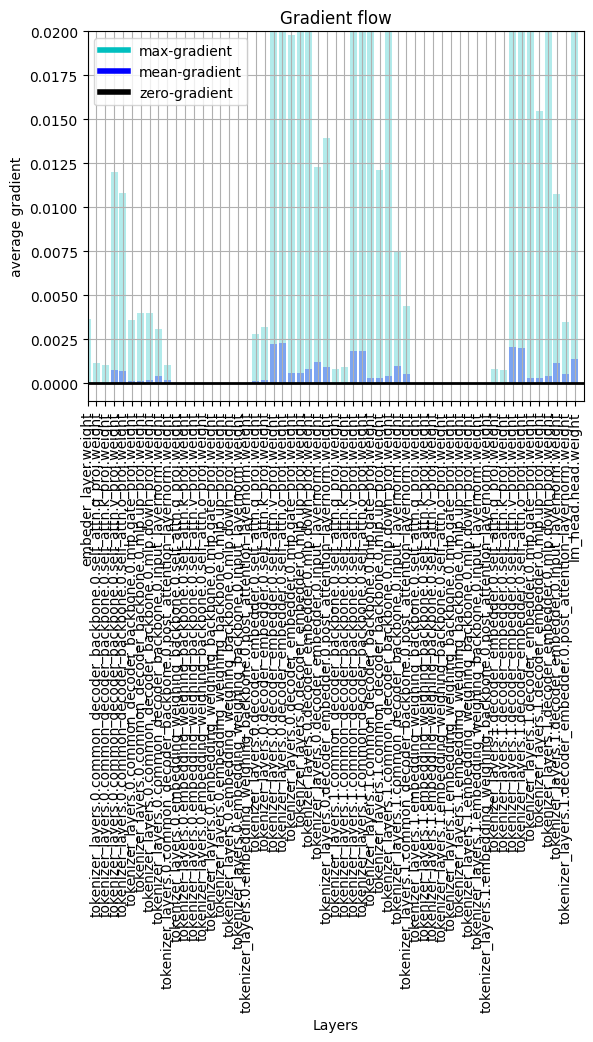

In [170]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
def plot_grad_flow(named_parameters):
    # https://gist.github.com/Flova/8bed128b41a74142a661883af9e51490
    '''Plots the gradients flowing through different layers in the net during training.
    Can be used for checking for possible gradient vanishing / exploding problems.
    
    Usage: Plug this function in Trainer class after loss.backwards() as 
    "plot_grad_flow(self.model.named_parameters())" to visualize the gradient flow'''
    ave_grads = []
    max_grads= []
    layers = []
    for n, p in named_parameters:
        if (p.requires_grad) and ("bias" not in n)\
            and not (p.grad is None):
            layers.append(n)
            ave_grads.append(p.grad.abs().mean().item())
            max_grads.append(p.grad.abs().max().item())
        if (p.grad is None):
            print("No gradient for:", n)
    plt.bar(np.arange(len(max_grads)), max_grads, alpha=0.3, lw=1, color="c")
    plt.bar(np.arange(len(max_grads)), ave_grads, alpha=0.3, lw=1, color="b")
    plt.hlines(0, 0, len(ave_grads)+1, lw=2, color="k" )
    plt.xticks(range(0,len(ave_grads), 1), layers, rotation="vertical")
    plt.xlim(left=0, right=len(ave_grads))
    plt.ylim(bottom = -0.001, top=0.02) # zoom in on the lower gradient regions
    plt.xlabel("Layers")
    plt.ylabel("average gradient")
    plt.title("Gradient flow")
    plt.grid(True)
    plt.legend([Line2D([0], [0], color="c", lw=4),
                Line2D([0], [0], color="b", lw=4),
                Line2D([0], [0], color="k", lw=4)], ['max-gradient', 'mean-gradient', 'zero-gradient'])
    
plot_grad_flow(tokenizer_model.named_parameters())

In [16]:
def loss_fn(model, batch):
    model(batch['input_ids'], batch['attention_mask'])
    loss = model.loss()

    return loss

In [17]:
from tqdm.notebook import tqdm

def train_loop(model, loss_function, train_dataset, pad_collator, learning_rate, batch_size, num_epochs=1):
    """
    batch_size = power of two between 2**0 and 2**6 (64), the largest that you can fit in memory

    """
    assert 1 <= batch_size <= 64, "batch size must be between 1 and 64"
    assert (batch_size & (batch_size-1) == 0) and batch_size != 0, "batch size must be a power of 2"
    assert num_epochs > 0

    # if 'num_workers' causes an error for you, then delete it
    loader_kwargs = {'batch_size': batch_size, 'collate_fn': pad_collator, 'pin_memory': True}
    train_dataloader = torch.utils.data.DataLoader(train_dataset, shuffle=True, **loader_kwargs)

    grad_acc_steps = 64 // batch_size  # accumulate gradients such that effective batch size is 64
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    train_steps = int(len(train_dataloader) * num_epochs)
    warmup = int(0.05 * train_steps) # 5% of total steps
    linear_warmup = lambda step: min(1.0, (step + 1) / (warmup + 1))
    lr_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=linear_warmup)

    # train loop
    model.train()
    with tqdm(total=train_steps) as pbar:
        for _ in range(num_epochs):
            for i, batch in enumerate(train_dataloader):
                # all batch elements to model device
                for k, v in batch.items():
                    if type(v) == torch.Tensor:
                        batch[k] = v.to(model.device)

                loss = loss_function(model, batch)
                pbar.set_postfix(loss=loss.item())

                # accumulate gradient
                loss /= grad_acc_steps
                loss.backward()

                # perform gradient step
                if (i + 1) % grad_acc_steps == 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # clip gradients
                    optimizer.step()
                    optimizer.zero_grad()
                lr_scheduler.step()

                pbar.update(1)

    model.eval()

In [312]:
train_loop(
    tokenizer_model,
    loss_fn,
    tokenized_wiki,
    pad_sft_collator,
    learning_rate=2e-5,
    batch_size=16,
    num_epochs=1,
)

  0%|          | 0/625 [00:00<?, ?it/s]

In [311]:
tokenizer_model.tokenization_pressure = 0.8

In [219]:
batch_idx = 1
bytes(padded_batch["input_ids"][batch_idx].tolist()[:21])

b'This is a list of cha'

In [315]:
softmax = nn.Softmax(dim=-1)
pos = 376
up_to = 513
probs = softmax(tokenizer_model(padded_batch["input_ids"][:,:up_to].to(device), padded_batch["attention_mask"][:,:up_to].to(device)))

In [316]:
i = 0

In [317]:
print(probs[1,i].argsort(descending=True))#.shape
i+=1

tensor([104, 111, 101, 117, 110, 108,  97,  48,  44,  76, 121,  98, 119,  41,
        195, 118, 114,  82,  51,  65,  75,  45,  34, 105, 120,  46,  56, 161,
         58,  88,  79, 113, 196, 122,  85, 197, 169,  39,  86,  59, 173,  47,
        128, 180, 158,  55,  96, 107,  40, 201, 229, 226,  77, 155,  10,  13,
        106, 143, 186, 232,  89,  69, 254, 125, 109,  61,  35,  81,  17, 206,
          5,  43,  52, 162, 242,  38,  14, 179, 220, 168, 253, 167, 255, 190,
         87, 223,  73, 214,   2, 217, 132, 160, 200, 239, 219, 165,   1, 102,
        225, 166,   6,  66, 151, 134,  92,  20,   9, 146, 133, 149,  30, 171,
        237, 215, 184, 221, 213,  33,  68, 208, 249, 124,  90,   4,  25, 174,
        139, 178, 159, 176, 194, 233, 240, 202,  71, 181, 231, 183, 175, 211,
        244, 130, 145,  21,  95, 116, 212,   3,  72, 222, 182, 250, 238, 185,
        153, 243,  63,  94, 218,  36,  54, 191,  62, 144,  24,  80, 127, 187,
         26,  91, 164, 252, 188,  53,  93,  12, 204, 137, 236, 2

In [318]:
tokenizer_model.lm_head.features.shape, tokenizer_model.lm_head.targets.shape

(torch.Size([2, 512, 257]), torch.Size([2, 512]))

In [321]:
thr = 0.1
bytes_past_thr_0 = padded_batch["input_ids"][batch_idx].to(device)[(tokenizer_model.tokenizer_layers[0].embedding_weights[batch_idx,:,0] > thr)]
bytes_past_thr_1 = padded_batch["input_ids"][batch_idx].to(device)[(tokenizer_model.tokenizer_layers[1].embedding_weights[batch_idx,:,0] > thr)]
print("input bytes:\t\t\t\t",bytes(padded_batch["input_ids"][batch_idx].tolist()))
print("bytes that pass the threshold:\t\t", bytes(bytes_past_thr_0.tolist()))
print("bytes that pass the threshold 2:\t", bytes(bytes_past_thr_1.tolist()))

input bytes:				 b'This is a list of characters from Downton Abbey, a British period drama television series created by Julian Fellowes and co-produced by Carnival Films and Masterpiece for ITV and PBS, respectively.\n\nCast\n\nMain cast\n\nRecurring cast\n\nGuest cast\n\nThe Crawley family\n\nRobert Crawley, 7th Earl of Grantham  \nRobert Crawley, 7th Earl of Grantham (played by Hugh Bonneville) (b. 1866) is the current Earl of Grantham. He is the husband of Cora, son of Violet, and father of Mary, Edith and Sybil. Robert is immensely pr'
bytes that pass the threshold:		 b'This is a list of characters from Downton Abbey, a British period drama television series created by Julian Fellowes and co-produced by Carnival Films and Masterpiece for ITV and PBS, respectively.\n\nCast\n\nMain cast\n\nRecurring cast\n\nGuest cast\n\nThe Crawley family\n\nRobert Crawley, 7th Earl of Grantham  \nRobert Crawley, 7th Earl of Grantham (played by Hugh Bonneville) (b. 1866) is the current Earl of Grant

In [389]:
tokenizer_model.tokenizer_layers[0].loss()#.embedding_weights[1]

tensor(0.9846, device='cuda:0', grad_fn=<MeanBackward0>)

In [323]:
b = 1
s = 1

In [387]:
ctx = padded_batch["input_ids"][b].tolist()[:s+1]
new_token = padded_batch["input_ids"][b].tolist()[s+1]
new_token_rank = probs[b, s].argsort(descending=True).tolist().index(new_token)
print(bytes(ctx).decode(),
      bytes([new_token]).decode())
print(new_token_rank)
s+=1

This is a list of characters from Downton Abbey, a British period  
0


In [27]:
emb_weights = tokenizer_model.tokenizer_layers[0].embedding_weights#.shape

In [28]:
emb_weights.shape

torch.Size([2, 512, 1])

In [29]:
batch_size = emb_weights.shape[0]
expansion = torch.tensor([1]).expand(batch_size, 1, 1).to(device)#.shape

In [30]:
torch.cat([emb_weights, expansion], dim=1)[:,-5:]

tensor([[[1.2112e-04],
         [7.3008e-05],
         [6.0400e-05],
         [4.5045e-05],
         [1.0000e+00]],

        [[1.8557e-04],
         [1.9522e-05],
         [8.8615e-05],
         [7.4197e-05],
         [1.0000e+00]]], device='cuda:0', grad_fn=<SliceBackward0>)

In [31]:
tokenizer_model.tokenizer_layers[0].loss()

tensor(7.0376e-05, device='cuda:0', grad_fn=<MeanBackward0>)

In [ ]:
text = "Albert Ein"
tokens = torch.tensor(list(text.encode()), device=device).unsqueeze(0)
bytes([nn.Softmax(dim=-1)(tokenizer_model(tokens)[0,-1]).argmax().item()]) 

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!